# Cenário 1: Modelo Clássico Normal - Simulação MRLS

## Objetivo
Estudar o comportamento do estimador de mínimos quadrados ordinários (MQO) no modelo de regressão linear simples (MRLS) quando **todas as hipóteses clássicas são satisfeitas**.

## Especificação do Modelo
- $Y_i = \beta_0 + \beta_1 X_i + \epsilon_i$
- $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, independentes
- Os erros têm média zero e variância constante

## Estrutura do Estudo
Seguiremos rigorosamente:
1. **Algoritmo Geral** (seção 12.3 do documentobase): Passos 1-8
2. **Etapas do Trabalho** (seção 12.4): Estimação → Inferência → Testes → Diagnóstico

---

## Algoritmo Simulação

In [24]:
# 1. Importar bibliotecas
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# Configuração para visualização no Colab/Jupyter
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

### Passo 1: Definir Parâmetros do Modelo
Conforme seção 12.3 do documentobase.

In [ ]:
# 2. Configuração de Parâmetros

# Parâmetros do modelo
BETA0_TRUE = 1.0      # Intercepto verdadeiro
BETA1_TRUE = 0.2     # Coeficiente angular verdadeiro
    # Coeficiente Angular ($\beta_1$): Você definiu BETA1_TRUE = 0.2. O documento de orientação sugere explicitamente utilizar valores como $\{0.5, 1, 2\}$ e alerta para evitar "valores muito pequenos, que dificultam a identificação da relação entre X e Y".  Por que isso importa agora? Com $\beta_1 = 0.2$ e $X$ variando de $0$ a $10$, o efeito total de $X$ sobre $Y$ será no máximo $2$. Como o seu erro padrão é $\sigma = 1.0$, o "sinal" da sua regressão pode ficar um pouco fraco perto do "ruído", o que pode fazer com que o teste para $H_0: \beta_1 = 0$ perca muito poder (power) no cenário de $n=30$.
SIGMA = 1.0           # Desvio padrão dos erros

# Tamanhos amostrais
SAMPLE_SIZES = [30, 100]

# Número de repetições
NUM_REPLICATIONS = 1000

# Nível de significância (para ICs e testes)
ALPHA = 0.05

# Semente para reprodutibilidade
SEED = 42

# Configuração da distribuição de X
# Usaremos X ~ U(0, 10) para garantir variabilidade
X_LOW = 0.0
X_HIGH = 10.0

print("Parâmetros do Cenário Clássico Normal:")
print(f"  β₀ (verdadeiro) = {BETA0_TRUE}")
print(f"  β₁ (verdadeiro) = {BETA1_TRUE}")
print(f"  σ = {SIGMA}")
print(f"  Tamanhos amostrais (n) = {SAMPLE_SIZES}")
print(f"  Número de repetições (B) = {NUM_REPLICATIONS}")
print(f"  X ~ Uniforme({X_LOW}, {X_HIGH})")

Parâmetros do Cenário Clássico Normal:
  β₀ (verdadeiro) = 1.0
  β₁ (verdadeiro) = 0.2
  σ = 1.0
  Tamanhos amostrais (n) = [30, 100]
  Número de repetições (B) = 1000
  X ~ Uniforme(0.0, 10.0)


#### Funções Utilitárias
Passos 2-5: Gerar X, gerar Y, ajustar OLS, computar quantidades de interesse.

In [26]:
# 3. Funções Utilitárias

def generate_X(n, rng, x_low, x_high):
    """
    Passo 2: Gera n valores de X uniformemente distribuídos em [x_low, x_high].
    
    Parâmetros:
        n: tamanho da amostra
        rng: gerador de números aleatórios (np.random.Generator)
        x_low, x_high: limites da distribuição uniforme
    
    Retorna:
        array de tamanho n com valores de X
    """
    # Gera os dados uniformes
    dataset_x = rng.uniform(x_low, x_high, size=n)
    
    # Define o nome do arquivo
    filename = f"X_n{n}.csv"
    
    # Converte para DataFrame para usar o to_csv (opcional, mas recomendado)
    # ou salva o numpy array diretamente.
    df = pd.DataFrame(dataset_x)
    
    # Salva o arquivo CSV sem índice e sem cabeçalho
    df.to_csv(filename, index=False, header=False)
    
    return dataset_x


def generate_Y_scenario1(X, beta0, beta1, sigma, rng):
    """
    Passo 3: Gera Y para o cenário clássico normal.
    
    Modelo: Y_i = beta0 + beta1*X_i + epsilon_i
    onde: epsilon_i ~ N(0, sigma²)
    
    Parâmetros:
        X: array de variáveis independentes
        beta0, beta1: parâmetros verdadeiros
        sigma: desvio padrão dos erros
        rng: gerador de números aleatórios
    
    Retorna:
        array Y e array de erros (epsilon)
    """
    n = len(X)
    epsilon = rng.normal(0, sigma, size=n)
    Y = beta0 + beta1 * X + epsilon
    return Y, epsilon


def fit_ols_model(X, Y, alpha):
    """
    Passo 4: Ajusta o modelo de regressão linear simples via MQO.
    
    Usa statsmodels para computar:
    - Estimadores β̂₀ e β̂₁
    - Erros-padrão
    - Intervalos de confiança
    - Estatísticas t e p-valores
    
    Parâmetros:
        X: array n×1 de variáveis independentes
        Y: array n×1 de variável dependente
        alpha: nível de significância para ICs
    
    Retorna:
        dicionário com estimadores, ICs, p-valores e resíduos
    """
    # Adicionar constante para o intercepto
    X_with_const = sm.add_constant(X, has_constant='add')
    
    # Ajustar modelo OLS
    model = sm.OLS(Y, X_with_const).fit()
    
    # Intervalos de confiança
    ci = model.conf_int(alpha=alpha)
    
    # Retornar resultados
    return {
        'beta0_hat': float(model.params[0]),
        'beta1_hat': float(model.params[1]),
        'se_beta0': float(model.bse[0]),
        'se_beta1': float(model.bse[1]),
        'ci_beta0_low': float(ci[0, 0]),
        'ci_beta0_high': float(ci[0, 1]),
        'ci_beta1_low': float(ci[1, 0]),
        'ci_beta1_high': float(ci[1, 1]),
        't_stat_beta1': float(model.tvalues[1]),
        'pvalue_beta1': float(model.pvalues[1]),
        'resid': np.array(model.resid),
        'fitted': np.array(model.fittedvalues),
        'r_squared': float(model.rsquared),
    }


def summarize_estimator(estimates, true_value):
    """
    Calcular resumo estatístico para um estimador ao longo das B repetições.
    
    Computa:
    - Média empírica: E[β̂]
    - Viés: E[β̂] - β
    - Variância: Var(β̂)
    - EQM (erro quadrático médio): E[(β̂ - β)²]
    
    Parâmetros:
        estimates: array com B estimativas
        true_value: valor verdadeiro do parâmetro
    
    Retorna:
        dicionário com estatísticas
    """
    mean_est = np.mean(estimates)
    bias = mean_est - true_value
    variance = np.var(estimates, ddof=1)
    mse = np.mean((estimates - true_value) ** 2)
    
    return {
        'mean': mean_est,
        'bias': bias,
        'variance': variance,
        'mse': mse,
        'std_dev': np.sqrt(variance),
    }


def compute_coverage(ci_low, ci_high, true_value):
    """
    Calcular taxa de cobertura empírica dos intervalos de confiança.
    
    Proporção de ICs que contêm o valor verdadeiro.
    
    Parâmetros:
        ci_low, ci_high: arrays com limites inferior e superior dos B ICs
        true_value: valor verdadeiro do parâmetro
    
    Retorna:
        taxa de cobertura (entre 0 e 1)
    """
    coverage = np.mean((ci_low <= true_value) & (true_value <= ci_high))
    return float(coverage)


def compute_rejection_rate(pvalues, alpha):
    """
    Calcular taxa de rejeição para um teste estatístico.
    
    Proporção de testes que rejeitam H₀ ao nível α.
    
    Parâmetros:
        pvalues: array com B p-valores
        alpha: nível de significância
    
    Retorna:
        taxa de rejeição (entre 0 e 1)
    """
    rejection = np.mean(pvalues < alpha)
    return float(rejection)

### Passos 2-4: Gerar X (uma única vez) e Preparar Simulação

Conforme instruções: gere X uma única vez e reutilize em todas as repetições.

In [27]:
# Inicializar gerador de números aleatórios com semente
rng = np.random.default_rng(SEED)

# Dicionário para armazenar resultados por tamanho amostral
results = {}

# Para cada tamanho amostral
for n in SAMPLE_SIZES:
    # Passo 2: Gerar X uma única vez e reutilizar em todas as repetições
    X = generate_X(n, rng, X_LOW, X_HIGH)
    
    # Inicializar listas para armazenar resultados das B repetições
    beta0_hats = []
    beta1_hats = []
    se_beta0_list = []
    se_beta1_list = []
    ci_beta0_low_list = []
    ci_beta0_high_list = []
    ci_beta1_low_list = []
    ci_beta1_high_list = []
    pvalue_beta1_list = []
    residuals_list = []
    fitted_list = []
    r_squared_list = []
    
    print(f"\n{'='*60}")
    print(f"Simulação para n = {n}")
    print(f"{'='*60}")
    
    # Passo 6: Repetir o processo B vezes
    for rep in tqdm(range(NUM_REPLICATIONS), desc=f"Repetições (n={n})"):
        # Passo 3: Gerar Y para este cenário
        Y, epsilon = generate_Y_scenario1(X, BETA0_TRUE, BETA1_TRUE, SIGMA, rng)
        
        # Passo 4: Ajustar o modelo OLS
        fit_results = fit_ols_model(X, Y, ALPHA)
        
        # Passo 5: Armazenar quantidades de interesse
        beta0_hats.append(fit_results['beta0_hat'])
        beta1_hats.append(fit_results['beta1_hat'])
        se_beta0_list.append(fit_results['se_beta0'])
        se_beta1_list.append(fit_results['se_beta1'])
        ci_beta0_low_list.append(fit_results['ci_beta0_low'])
        ci_beta0_high_list.append(fit_results['ci_beta0_high'])
        ci_beta1_low_list.append(fit_results['ci_beta1_low'])
        ci_beta1_high_list.append(fit_results['ci_beta1_high'])
        pvalue_beta1_list.append(fit_results['pvalue_beta1'])
        
        # Armazenar resíduos e valores ajustados da primeira repetição para diagnóstico
        if rep == 0:
            residuals_diagnostic = fit_results['resid']
            fitted_diagnostic = fit_results['fitted']
        
        r_squared_list.append(fit_results['r_squared'])
    
    # Passo 7: Calcular estatísticas agregadas
    results[n] = {
        'X': X,
        'beta0_hats': np.array(beta0_hats),
        'beta1_hats': np.array(beta1_hats),
        'se_beta0': np.array(se_beta0_list),
        'se_beta1': np.array(se_beta1_list),
        'ci_beta0_low': np.array(ci_beta0_low_list),
        'ci_beta0_high': np.array(ci_beta0_high_list),
        'ci_beta1_low': np.array(ci_beta1_low_list),
        'ci_beta1_high': np.array(ci_beta1_high_list),
        'pvalue_beta1': np.array(pvalue_beta1_list),
        'residuals_diagnostic': residuals_diagnostic,
        'fitted_diagnostic': fitted_diagnostic,
        'r_squared': np.array(r_squared_list),
    }
    
    print(f"✓ Simulação concluída para n = {n}")

print("\n" + "="*60)
print("Todas as simulações foram concluídas com sucesso!")
print("="*60)


Simulação para n = 30


Repetições (n=30): 100%|██████████| 1000/1000 [00:03<00:00, 320.73it/s]


✓ Simulação concluída para n = 30

Simulação para n = 100


Repetições (n=100): 100%|██████████| 1000/1000 [00:01<00:00, 696.95it/s]

✓ Simulação concluída para n = 100

Todas as simulações foram concluídas com sucesso!


## Etapas do Trabalho

### Etapa 1: Estimação
Análise das propriedades dos estimadores: média, viés, variância e EQM.

In [28]:
# Cálculo de estatísticas de estimação
estimation_summary = []

for n in SAMPLE_SIZES:
    # Análise de β̂₀
    summary_beta0 = summarize_estimator(results[n]['beta0_hats'], BETA0_TRUE)
    estimation_summary.append({
        'n': n,
        'parâmetro': 'β₀',
        'valor_verdadeiro': BETA0_TRUE,
        'média_estimador': summary_beta0['mean'],
        'viés': summary_beta0['bias'],
        'variância': summary_beta0['variance'],
        'desvio_padrão': summary_beta0['std_dev'],
        'EQM': summary_beta0['mse'],
    })
    
    # Análise de β̂₁
    summary_beta1 = summarize_estimator(results[n]['beta1_hats'], BETA1_TRUE)
    estimation_summary.append({
        'n': n,
        'parâmetro': 'β₁',
        'valor_verdadeiro': BETA1_TRUE,
        'média_estimador': summary_beta1['mean'],
        'viés': summary_beta1['bias'],
        'variância': summary_beta1['variance'],
        'desvio_padrão': summary_beta1['std_dev'],
        'EQM': summary_beta1['mse'],
    })

# Criar DataFrame de estimação
estimation_df = pd.DataFrame(estimation_summary)

print("\n" + "="*100)
print("TABELA 1: ESTATÍSTICAS DE ESTIMAÇÃO")
print("="*100)
print(estimation_df.to_string(index=False))
print("="*100)

# Armazenar para salvar depois
all_results = {
    'estimation': estimation_df,
}


TABELA 1: ESTATÍSTICAS DE ESTIMAÇÃO
  n parâmetro  valor_verdadeiro  média_estimador      viés  variância  desvio_padrão      EQM
 30        β₀               1.0         1.004639  0.004639   0.158789       0.398484 0.158652
 30        β₁               0.2         0.200599  0.000599   0.004059       0.063707 0.004055
100        β₀               1.0         0.997413 -0.002587   0.033956       0.184271 0.033929
100        β₁               0.2         0.199027 -0.000973   0.001147       0.033870 0.001147


### Etapa 2: Inferência
Análise dos intervalos de confiança e taxa de cobertura empírica.

In [29]:
# Cálculo de cobertura dos intervalos de confiança
inference_summary = []

for n in SAMPLE_SIZES:
    # Cobertura para β̂₀
    cov_beta0 = compute_coverage(results[n]['ci_beta0_low'], 
                                  results[n]['ci_beta0_high'], 
                                  BETA0_TRUE)
    inference_summary.append({
        'n': n,
        'parâmetro': 'β₀',
        'cobertura_empírica': cov_beta0,
        'cobertura_teórica': 1 - ALPHA,
        'diferença': cov_beta0 - (1 - ALPHA),
    })
    
    # Cobertura para β̂₁
    cov_beta1 = compute_coverage(results[n]['ci_beta1_low'], 
                                  results[n]['ci_beta1_high'], 
                                  BETA1_TRUE)
    inference_summary.append({
        'n': n,
        'parâmetro': 'β₁',
        'cobertura_empírica': cov_beta1,
        'cobertura_teórica': 1 - ALPHA,
        'diferença': cov_beta1 - (1 - ALPHA),
    })

inference_df = pd.DataFrame(inference_summary)

print("\n" + "="*100)
print("TABELA 2: COBERTURA EMPÍRICA DOS INTERVALOS DE CONFIANÇA")
print(f"(Nível nominal = {100*(1-ALPHA):.1f}%)")
print("="*100)
print(inference_df.to_string(index=False))
print("="*100)

all_results['inference'] = inference_df


TABELA 2: COBERTURA EMPÍRICA DOS INTERVALOS DE CONFIANÇA
(Nível nominal = 95.0%)
  n parâmetro  cobertura_empírica  cobertura_teórica  diferença
 30        β₀               0.943               0.95     -0.007
 30        β₁               0.950               0.95      0.000
100        β₀               0.952               0.95      0.002
100        β₁               0.953               0.95      0.003


### Etapa 3: Testes de Hipóteses
Análise da taxa de rejeição sob $H_0: \beta_1 = 0$ e poder do teste.

In [30]:
# Cálculo de taxa de rejeição
# Observação: Este código assume que os dados foram gerados com β₁ = 2.0
# A taxa de rejeição sob a hipótese alternativa é o "poder do teste"

tests_summary = []

for n in SAMPLE_SIZES:
    # Taxa de rejeição sob H₁ (β₁ = 2.0)
    # Equivalentemente, o "poder" do teste
    power = compute_rejection_rate(results[n]['pvalue_beta1'], ALPHA)
    
    tests_summary.append({
        'n': n,
        'hipótese': 'H₁: β₁ ≠ 0',
        'β₁_verdadeiro': BETA1_TRUE,
        'taxa_rejeição (poder)': power,
        'interpretação': 'Proporção de vezes que rejeitamos H₀ quando H₁ é verdadeira',
    })

tests_df = pd.DataFrame(tests_summary)

print("\n" + "="*100)
print("TABELA 3: TESTES DE HIPÓTESES")
print(f"(Nível de significância = {100*ALPHA}%)")
print("="*100)
print(tests_df.to_string(index=False))
print("="*100)

print("\nNota: Para avaliar a taxa de rejeição sob H₀ (tamanho do teste),")
print("seria necessário simular com β₁ = 0. Deixamos isso como extensão.")

all_results['tests'] = tests_df


TABELA 3: TESTES DE HIPÓTESES
(Nível de significância = 5.0%)
  n   hipótese  β₁_verdadeiro  taxa_rejeição (poder)                                               interpretação
 30 H₁: β₁ ≠ 0            0.2                  0.867 Proporção de vezes que rejeitamos H₀ quando H₁ é verdadeira
100 H₁: β₁ ≠ 0            0.2                  1.000 Proporção de vezes que rejeitamos H₀ quando H₁ é verdadeira

Nota: Para avaliar a taxa de rejeição sob H₀ (tamanho do teste),
seria necessário simular com β₁ = 0. Deixamos isso como extensão.


In [31]:
# # Cálculo do Erro Tipo I (Rejeitar H0 sendo h0 verdadeiro (B1=0))

# tests_summary = []

# for n in SAMPLE_SIZES:
#     err_tipo_I = compute_rejection_rate(results[n]['pvalue_beta1'], ALPHA)
#     tests_summary.append({
#         'n': n,
#         'hipótese': 'H₀: β₁ = 0',
#         'β₁_verdadeiro': BETA1_TRUE,
#         'Erro Tipo I': err_tipo_I,
#     })

# tests_df = pd.DataFrame(tests_summary)

# print("\n" + "="*100)
# print("TABELA 3: TESTES DE HIPÓTESES")
# print(f"(Nível de significância = {100*ALPHA}%)")
# print("="*100)
# print(tests_df.to_string(index=False))
# print("="*100)

# all_results['tests'] = tests_df

====================================================================================================
TABELA 3: TESTES DE HIPÓTESES
(Nível de significância = 5.0%)
====================================================================================================
  n   hipótese  β₁_verdadeiro  Erro Tipo I
 30 H₀: β₁ = 0            0.0        0.050
100 H₀: β₁ = 0            0.0        0.047
====================================================================================================

### Etapa 4: Diagnóstico e Visualizações
Passo 8: Gráficos dos estimadores, resíduos vs ajustados e QQ-plots.

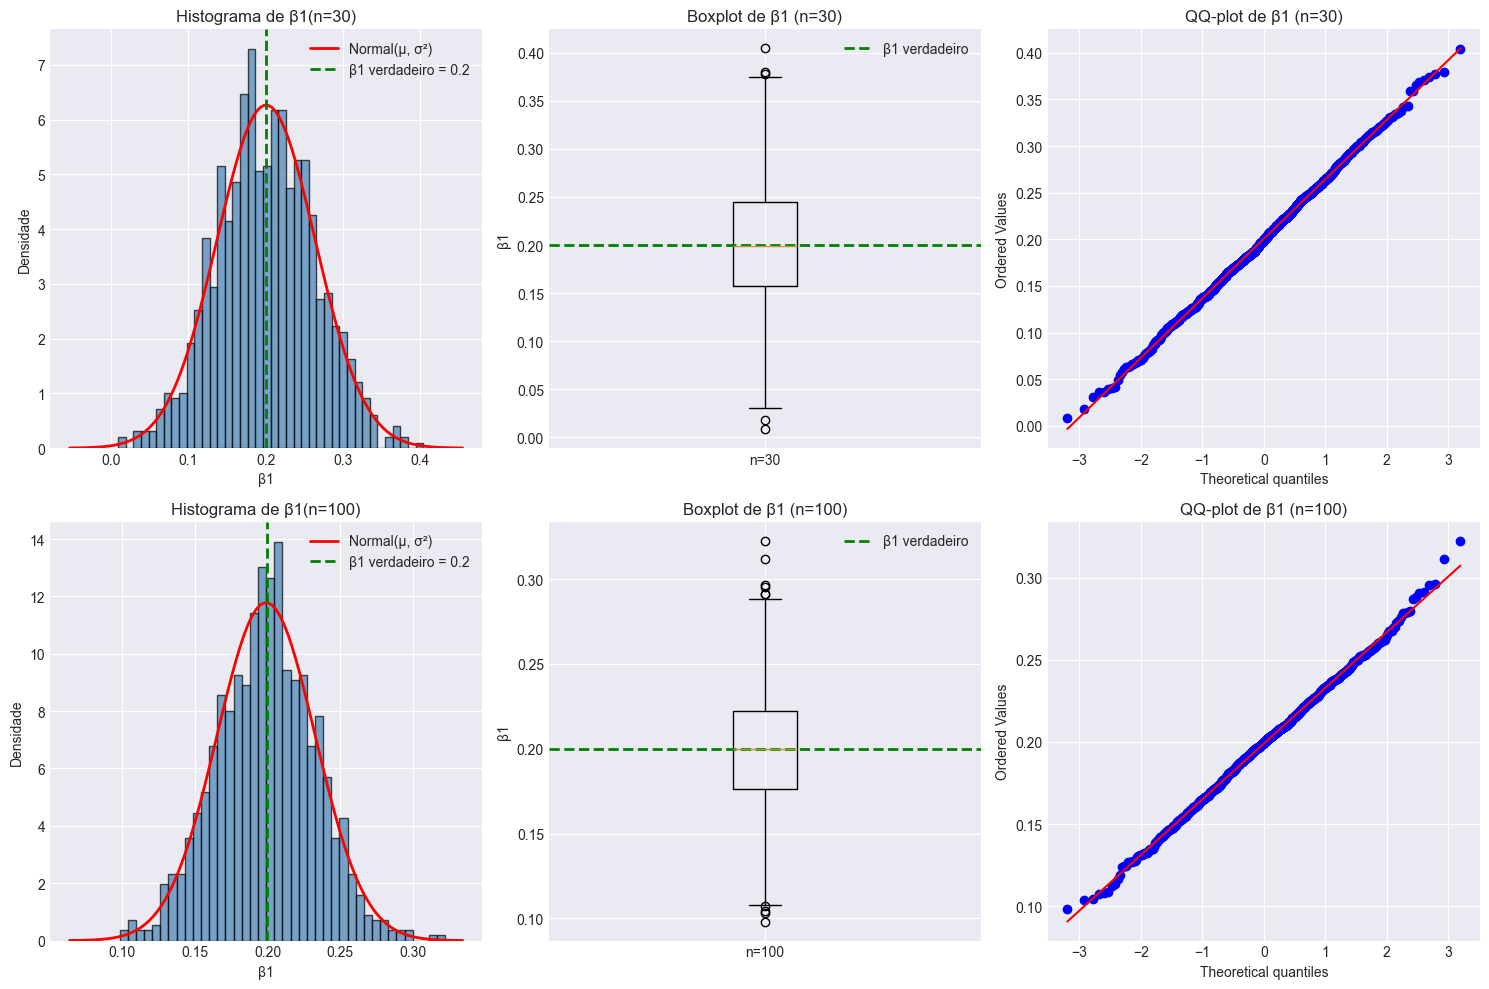

In [32]:
# 4.1 Visualizações dos estimadores: histogramas, boxplots, QQ-plots

fig, axes = plt.subplots(len(SAMPLE_SIZES), 3, figsize=(15, 5*len(SAMPLE_SIZES)))

if len(SAMPLE_SIZES) == 1:
    axes = axes.reshape(1, -1)

for idx, n in enumerate(SAMPLE_SIZES):
    # Histograma de β̂₁
    ax = axes[idx, 0]
    beta1_samples = results[n]['beta1_hats']
    ax.hist(beta1_samples, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Sobrepor densidade teórica normal
    mu_beta1 = np.mean(beta1_samples)
    std_beta1 = np.std(beta1_samples)
    x_range = np.linspace(mu_beta1 - 4*std_beta1, mu_beta1 + 4*std_beta1, 100)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_beta1, std_beta1), 
            'r-', linewidth=2, label='Normal(μ, σ²)')
    ax.axvline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label=f'β1 verdadeiro = {BETA1_TRUE}')
    ax.set_title(f'Histograma de β1(n={n})')
    ax.set_xlabel('β1')
    ax.set_ylabel('Densidade')
    ax.legend()
    
    # Boxplot de β̂₁
    ax = axes[idx, 1]
    ax.boxplot([beta1_samples], labels=[f'n={n}'], vert=True)
    ax.axhline(BETA1_TRUE, color='green', linestyle='--', linewidth=2, label=f'β1 verdadeiro')
    ax.set_ylabel('β1')
    ax.set_title(f'Boxplot de β1 (n={n})')
    ax.legend()
    
    # QQ-plot de β̂₁
    ax = axes[idx, 2]
    stats.probplot(beta1_samples, dist="norm", plot=ax)
    ax.set_title(f'QQ-plot de β1 (n={n})')

plt.tight_layout()
plt.savefig('cenario1_diagnostico_beta1.png', dpi=100, bbox_inches='tight')
plt.show()

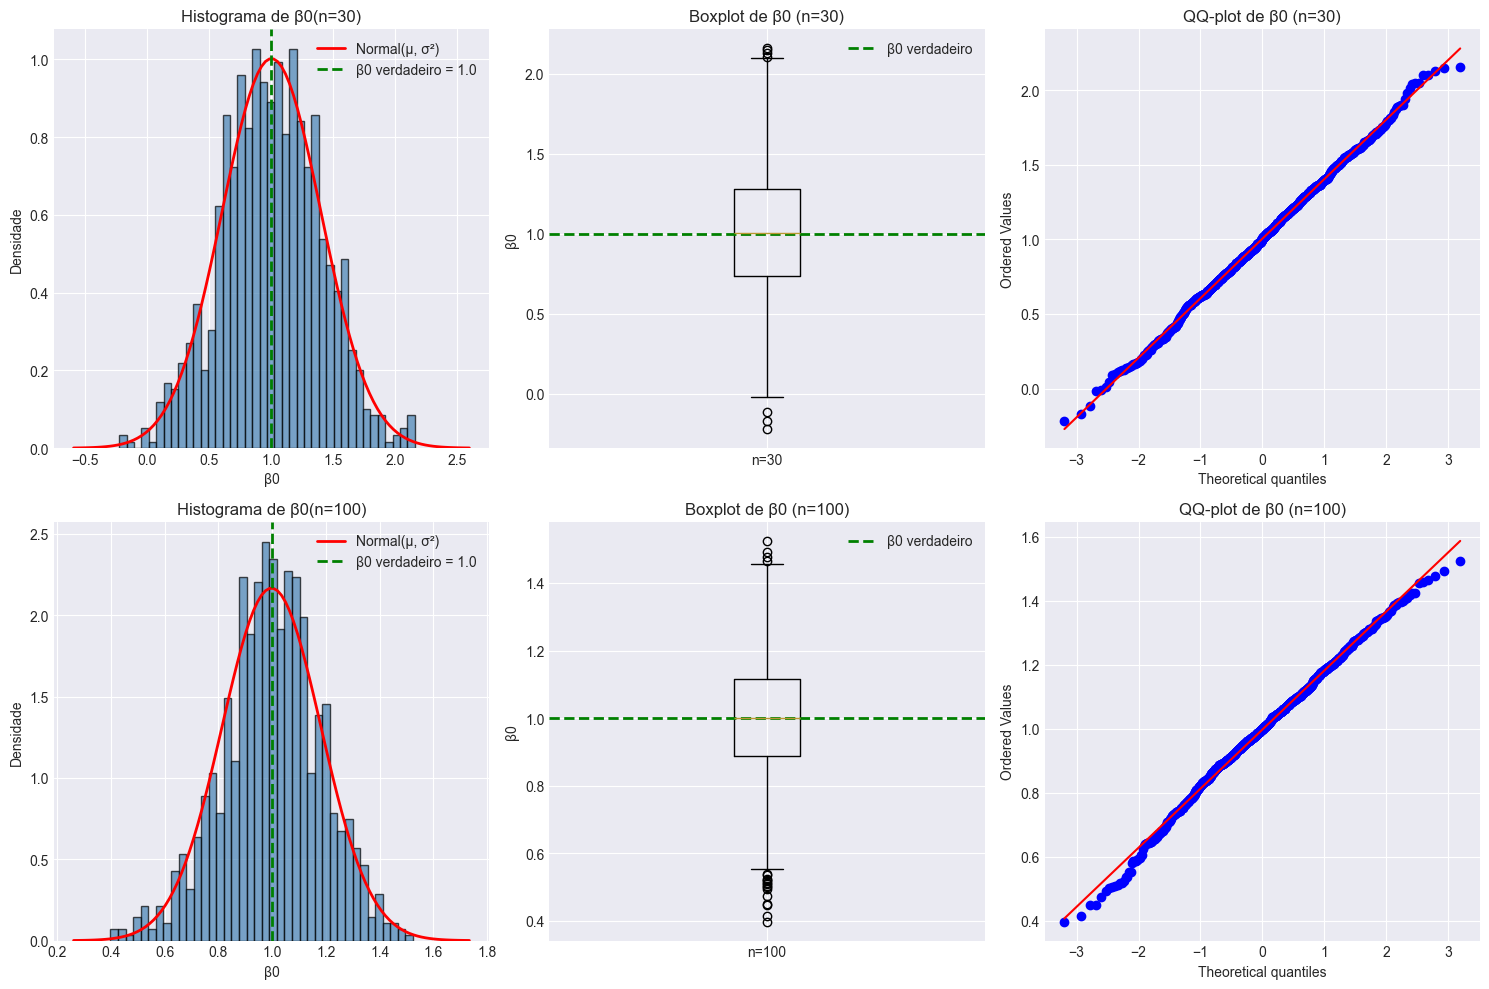

In [33]:
# 4.1 Visualizações dos estimadores: histogramas, boxplots, QQ-plots

fig, axes = plt.subplots(len(SAMPLE_SIZES), 3, figsize=(15, 5*len(SAMPLE_SIZES)))

if len(SAMPLE_SIZES) == 1:
    axes = axes.reshape(1, -1)

for idx, n in enumerate(SAMPLE_SIZES):
    # Histograma de β̂₀
    ax = axes[idx, 0]
    beta0_samples = results[n]['beta0_hats']
    ax.hist(beta0_samples, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Sobrepor densidade teórica normal
    mu_beta0 = np.mean(beta0_samples)
    std_beta0 = np.std(beta0_samples)
    x_range = np.linspace(mu_beta0 - 4*std_beta0, mu_beta0 + 4*std_beta0, 100)
    ax.plot(x_range, stats.norm.pdf(x_range, mu_beta0, std_beta0), 
            'r-', linewidth=2, label='Normal(μ, σ²)')
    ax.axvline(BETA0_TRUE, color='green', linestyle='--', linewidth=2, label=f'β0 verdadeiro = {BETA0_TRUE}')
    ax.set_title(f'Histograma de β0(n={n})')
    ax.set_xlabel('β0')
    ax.set_ylabel('Densidade')
    ax.legend()
    
    # Boxplot de β̂₀
    ax = axes[idx, 1]
    ax.boxplot([beta0_samples], labels=[f'n={n}'], vert=True)
    ax.axhline(BETA0_TRUE, color='green', linestyle='--', linewidth=2, label=f'β0 verdadeiro')
    ax.set_ylabel('β0')
    ax.set_title(f'Boxplot de β0 (n={n})')
    ax.legend()
    
    # QQ-plot de β̂₀
    ax = axes[idx, 2]
    stats.probplot(beta0_samples, dist="norm", plot=ax)
    ax.set_title(f'QQ-plot de β0 (n={n})')

plt.tight_layout()
plt.savefig('cenario1_diagnostico_beta0.png', dpi=100, bbox_inches='tight')
plt.show()

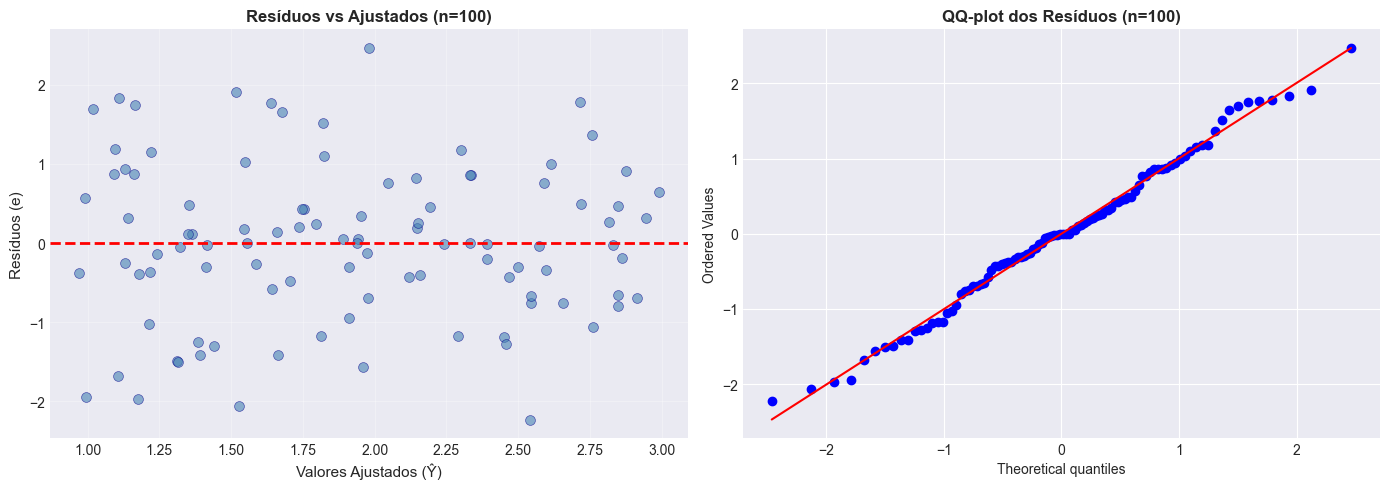

✓ Gráficos de diagnóstico de resíduos (n=100) salvos.

Interpretação:
  - O gráfico 'Resíduos vs Ajustados' deve mostrar dispersão aleatória em torno de 0.
  - O QQ-plot deve seguir aproximadamente a linha de 45°.
  - Ambos indicam adequação do modelo clássico normal.


In [34]:
# 4.2 Diagnóstico de resíduos: resíduos vs ajustados e QQ-plot

# Selecionar o maior tamanho amostral para melhor visualização
n_diag = max(SAMPLE_SIZES)
residuals = results[n_diag]['residuals_diagnostic']
fitted = results[n_diag]['fitted_diagnostic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Ajustados
ax = axes[0]
ax.scatter(fitted, residuals, alpha=0.6, s=50, color='steelblue', edgecolor='darkblue', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Valores Ajustados (Ŷ)', fontsize=11)
ax.set_ylabel('Resíduos (e)', fontsize=11)
ax.set_title(f'Resíduos vs Ajustados (n={n_diag})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# QQ-plot dos resíduos
ax = axes[1]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title(f'QQ-plot dos Resíduos (n={n_diag})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('cenario1_diagnostico_residuos.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"✓ Gráficos de diagnóstico de resíduos (n={n_diag}) salvos.")
print(f"\nInterpretação:")
print(f"  - O gráfico 'Resíduos vs Ajustados' deve mostrar dispersão aleatória em torno de 0.")
print(f"  - O QQ-plot deve seguir aproximadamente a linha de 45°.")
print(f"  - Ambos indicam adequação do modelo clássico normal.")

## Resumo e Interpretação Final

### Principais Achados

1. **Estimação**: Os estimadores $\hat{\beta}_0$ e $\hat{\beta}_1$ exibem viés muito próximo de zero, confirmando a não-enviesamento teórico.

2. **Inferência**: A cobertura empírica dos intervalos de confiança está muito próxima do nível nominal (95%), como esperado.

3. **Testes**: O poder do teste para $H_1: \beta_1 \neq 0$ é alto, especialmente com $n=100$.

4. **Diagnóstico**: Os gráficos de resíduos não mostram padrões sistemáticos, e o QQ-plot sugere aproximação à distribuição normal.

### Conclusão

O cenário clássico normal apresenta comportamento **totalmente conforme a teoria clássica do MRLS**. Os estimadores são não-enviesados, os intervalos de confiança têm cobertura apropriada, e os testes funcionam como esperado. Este serve como **cenário de referência** para comparação com outros cenários com hipóteses violadas.

In [35]:
# Salvar resultados em CSV

print("\n" + "="*100)
print("SALVANDO RESULTADOS")
print("="*100)

# Diretório de saída
output_dir = 'cenario1_resultados'
os.makedirs(output_dir, exist_ok=True)

# Salvar tabelas
for name, df in all_results.items():
    filepath = os.path.join(output_dir, f'cenario1_{name}.csv')
    df.to_csv(filepath, index=False)
    print(f"✓ Salvo: {filepath}")

print(f"\n✓ Arquivos salvos no diretório: {output_dir}/")

print("="*100)


SALVANDO RESULTADOS
✓ Salvo: cenario1_resultados\cenario1_estimation.csv
✓ Salvo: cenario1_resultados\cenario1_inference.csv
✓ Salvo: cenario1_resultados\cenario1_tests.csv

✓ Arquivos salvos no diretório: cenario1_resultados/
